In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../data/techcrunch.csv")

In [3]:
df.head()

,permalink,company,numEmps,category,city,state,fundedDate,raisedAmt,raisedCurrency,round
0,lifelock,LifeLock,NaN,web,Tempe,AZ,1-May-07,6850000,USD,b
1,lifelock,LifeLock,NaN,web,Tempe,AZ,1-Oct-06,6000000,USD,a
2,lifelock,LifeLock,NaN,web,Tempe,AZ,1-Jan-08,25000000,USD,c
3,mycityfaces,MyCityFaces,7.0,web,Scottsdale,AZ,1-Jan-08,50000,USD,seed
4,flypaper,Flypaper,NaN,web,Phoenix,AZ,1-Feb-08,3000000,USD,a


In [4]:
df.shape

(1460, 10)

In [5]:
df.dtypes

permalink             str
company               str
numEmps           float64
category              str
city                  str
state                 str
fundedDate            str
raisedAmt           int64
raisedCurrency        str
round                 str
dtype: object

In [6]:
df.isna().mean().sort_values(ascending=False)*100

numEmps           61.164384
category           1.643836
city               1.232877
permalink          0.000000
company            0.000000
state              0.000000
fundedDate         0.000000
raisedAmt          0.000000
raisedCurrency     0.000000
round              0.000000
dtype: float64

# *Vu la proportion de données manquantes dans la colonne numEmps (soit 61.2%), il est préférale de l'omettre dans notre analyse*
# *Pour la colonne category on remplace les données manquantes par* ~ unknown et on laisse colonne city avec ses 1.2% de NA 

In [7]:
#Suppression de la colonne numEmp 
df.drop(columns=['numEmps'], errors='ignore', inplace=True)

In [8]:
#remplissage des valeurs manquantes de la colonne category avec la valeur "Unknown"
df['category'] = df['category'].fillna('unknown') 

In [9]:
df.columns

Index(['permalink', 'company', 'category', 'city', 'state', 'fundedDate',
       'raisedAmt', 'raisedCurrency', 'round'],
      dtype='str')

In [10]:
df['fundedDate'] = pd.to_datetime(df['fundedDate'], format='%d-%b-%y')

In [11]:
df.isna().sum()

permalink          0
company            0
category           0
city              18
state              0
fundedDate         0
raisedAmt          0
raisedCurrency     0
round              0
dtype: int64

In [12]:
df.dtypes

permalink                    str
company                      str
category                     str
city                         str
state                        str
fundedDate        datetime64[us]
raisedAmt                  int64
raisedCurrency               str
round                        str
dtype: object

In [13]:
df['fundedDate'].dt.year.agg(['min', 'max'])

min    1993
max    2008
Name: fundedDate, dtype: int32

In [14]:
df['fundedDate'].dt.year.value_counts().sort_index()

fundedDate
1993      1
1999     14
2000     17
2001     13
2002     12
2003     27
2004     60
2005    128
2006    253
2007    538
2008    397
Name: count, dtype: int64

## Analyse exploratoire 

In [15]:
df.columns

Index(['permalink', 'company', 'category', 'city', 'state', 'fundedDate',
       'raisedAmt', 'raisedCurrency', 'round'],
      dtype='str')

In [17]:
df["raisedAmt"].describe()

count    1.460000e+03
mean     1.013149e+07
std      1.866146e+07
min      6.000000e+03
25%      2.000000e+06
50%      5.500000e+06
75%      1.102500e+07
max      3.000000e+08
Name: raisedAmt, dtype: float64

 La moyenne des montants levés s'élève à environ 10.1 M$, soit près du double de la médiane (5.5 M$
). Cet écart révèle une distribution asymétrique à droite (vers les grandes valeurs) : quelques méga-levées jusqu'à 300 M$  tirent la moyenne vers le haut, alors que la médiane y reste insensible. Pour décrire une levée de fonds typique dans le README, on retiendra donc la médiane, car elle est insensible aux valeurs extrêmes, contrairement à la moyenne. 

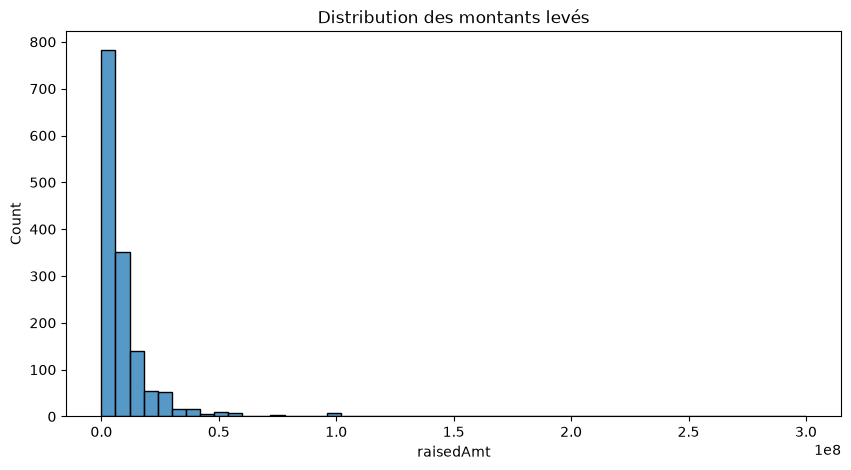

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df['raisedAmt'], bins=50)
plt.title('Distribution des montants levés')
plt.show()

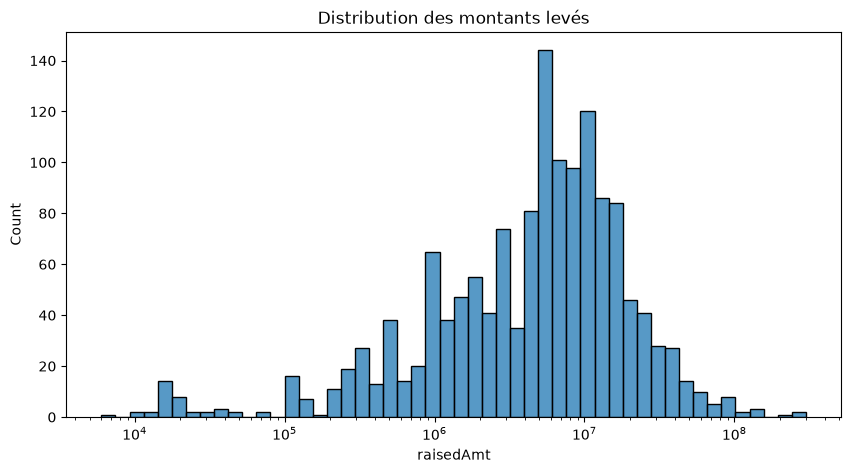

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df['raisedAmt'], bins=50, log_scale=True)
plt.title('Distribution des montants levés')
plt.show()

 ## En échelle naturelle, l'histogramme est illisible : la quasi-totalité des levées s'écrase dans les cinq premières barres, tandis que la longue queue vers les grandes valeurs (jusqu'à 300 M$) laisse le graphique presque vide. Le passage en échelle logarithmique résout le problème car il compresse les écarts entre les petites valeurs (10⁴ $) et les très grandes (10⁸ $), donnant un poids visuel comparable à chaque ordre de grandeur. La distribution révèle alors une forme en cloche quasi symétrique signature d'une distribution dite «log-normale», classique pour des données financières avec un pic entre 1 M$ et 10 M$,cohérent avec la médiane de 5.5 M$ calculée en Q4.

In [23]:
df.groupby('round')['raisedAmt'].median().sort_values(ascending=False)

round
d               24900000.0
e               22000000.0
c               15000000.0
b                9500000.0
unattributed     6100000.0
a                4500000.0
debt_round       2000000.0
angel             800000.0
seed              345000.0
Name: raisedAmt, dtype: float64

In [24]:
df['round'].value_counts()

round
a               582
b               371
c               141
angel           135
seed            128
d                47
unattributed     28
debt_round       17
e                11
Name: count, dtype: int64